# Datos de alumno

Estudiante: Octavio Quintero Flores

Matricula: 266226

Maestría en Inteligencia Artificial y Analítica de Datos

#Librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

#Funcion

In [ ]:
def curva_complejidad(noise):
    X, y = make_moons(n_samples=500, noise=noise, random_state=42)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    depths = range(1, 21)
    train_acc = []
    test_acc = []

    for d in depths:
        model = DecisionTreeClassifier(max_depth=d, random_state=42)
        model.fit(X_train, y_train)

        train_acc.append(model.score(X_train, y_train))
        test_acc.append(model.score(X_test, y_test))

    return depths, train_acc, test_acc

#Caso noise = 0.05

In [ ]:
depths_005, train_005, test_005 = curva_complejidad(0.05)

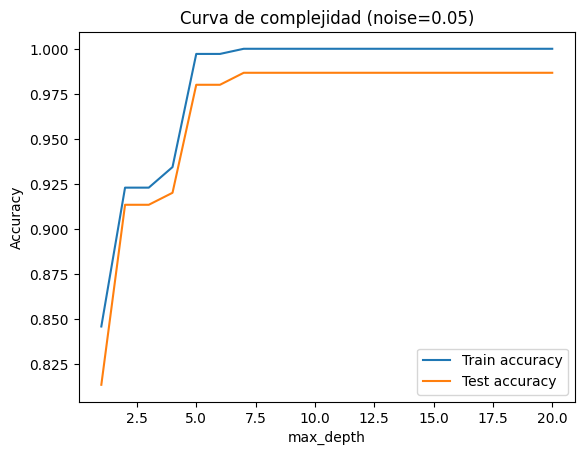

In [ ]:
plt.figure()
plt.plot(depths_005, train_005, label="Train accuracy")
plt.plot(depths_005, test_005, label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Curva de complejidad (noise=0.05)")
plt.legend()

plt.show()

**Underfitting (max_depth = 1 a 3):**
Se observa underfitting en profundidades bajas porque el modelo es demasiado simple para capturar la forma no lineal de las dos lunas.

* El árbol genera pocas divisiones, por lo que no logra separar correctamente las clases.
* Tanto el accuracy de entrenamiento como el de prueba son relativamente bajos.
* Esto indica que el modelo tiene alto sesgo (bias).

**Zona óptima (max_depth = 4 a 8):**
En este rango, el modelo logra capturar la estructura del dataset sin ajustarse demasiado a detalles irrelevantes.

* El accuracy de entrenamiento y prueba son altos y similares.
* Existe un buen equilibrio entre sesgo y varianza.

**Overfitting (max_depth ≥ 9):**
A partir de profundidades mayores, el modelo comienza a ajustarse demasiado incluso a pequeñas variaciones del dataset.

* El accuracy de entrenamiento alcanza valores cercanos a 1.
* El accuracy de prueba deja de mejorar o se estanca.
* Aunque hay poco ruido, el modelo empieza a memorizar detalles específicos del entrenamiento.
* Esto refleja alta varianza.

#Caso noise = 0.4

In [ ]:
depths_040, train_040, test_040 = curva_complejidad(0.40)

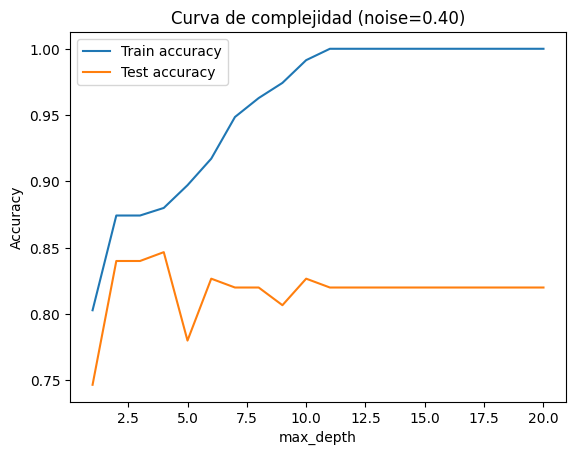

In [ ]:
plt.figure()
plt.plot(depths_040, train_040, label="Train accuracy")
plt.plot(depths_040, test_040, label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Curva de complejidad (noise=0.40)")
plt.legend()

plt.show()

**Underfitting (max_depth = 1 a 4):**
El modelo sigue siendo demasiado simple para capturar la complejidad de los datos, que ahora incluyen ruido.

* No logra distinguir correctamente los patrones reales.
* Accuracy bajo tanto en entrenamiento como en prueba.
* Predomina el alto sesgo.

**Zona óptima (max_depth = 5 a 7):**
El modelo encuentra un equilibrio adecuado.

* Captura la tendencia general sin intentar aprender el ruido.
* El accuracy de prueba alcanza su punto más alto en este rango.

**Overfitting (max_depth ≥ 8):**
El overfitting aparece más temprano que en el caso anterior debido al alto nivel de ruido.

* El modelo empieza a aprender patrones aleatorios que no generalizan.
* El accuracy de entrenamiento sigue aumentando.
* El accuracy de prueba disminuye o fluctúa negativamente.
* El modelo presenta alta varianza, siendo muy sensible al ruido.